downloaded: cosmon_c103_r005-8_deuteron_Swave.hdf5
Sector: PSQ0_T1g
N_samples = 1490  N_op = 15  Nt = 26
condition number xi_cn = 1.8015398737221169
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.4301707766562934 +/- 0.00029844134202534954

Sector: PSQ1_A2
N_samples = 1490  N_op = 10  Nt = 26
condition number xi_cn = 1.5992118253058865
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.4411637049468313 +/- 0.0003053467023381665

Sector: PSQ1_E
N_samples = 1490  N_op = 18  Nt = 26
condition number xi_cn = 1.6159377511735675
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.4415645489767597 +/- 0.0002937950258151779

Sector: PSQ2_A2
N_samples = 1490  N_op = 15  Nt = 26
condition number xi_cn = 1.5969515895881912
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.4525306212191067 +/- 0.000297026955211931

Sector: PSQ2_B1
N_samples = 1490  N_op = 19  Nt = 26
condition number xi_cn = 1.6096805996605896
post

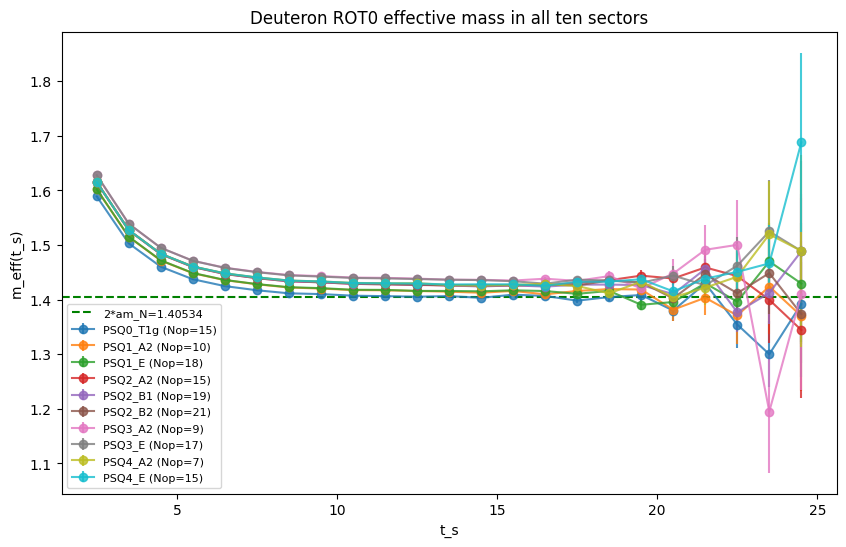

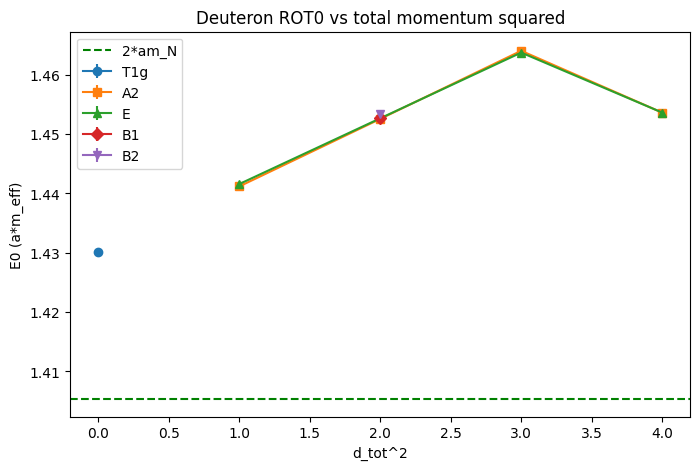

Deuteron: irrep-averaged lab-frame energies
 d_tot^2             E0          err
       0       1.430171     0.000298
       1       1.441431     0.000220
       2       1.452810     0.000171
       3       1.463799     0.000218
       4       1.453597     0.000218

Reference: 2*am_N = 1.40534
 d_tot^2         E0-2mN          err       E0/(2mN)
       0       0.024831     0.000298       1.017669
       1       0.036091     0.000220       1.025681
       2       0.047470     0.000171       1.033779
       3       0.058459     0.000218       1.041598
       4       0.048257     0.000218       1.034339


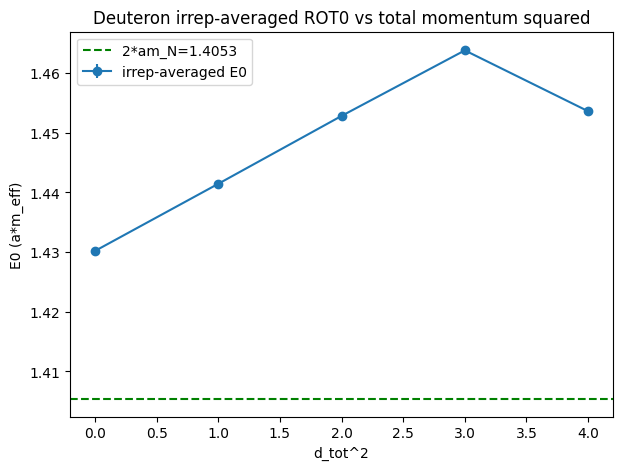

Summary: deuteron ROT0 plateau values
sector      Nop     cond           E0       E0_err
PSQ0_T1g     15    1.802     1.430171     0.000298
PSQ1_A2      10    1.599     1.441164     0.000305
PSQ1_E       18    1.616     1.441565     0.000294
PSQ2_A2      15    1.597     1.452531     0.000297
PSQ2_B1      19    1.610     1.452603     0.000298
PSQ2_B2      21    1.599     1.453297     0.000296
PSQ3_A2       9    1.275     1.463999     0.000288
PSQ3_E       17    1.304     1.463699     0.000301
PSQ4_A2       7    1.585     1.453593     0.000282
PSQ4_E       15    1.593     1.453600     0.000298


In [4]:
import urllib.request

url="https://portal.nersc.gov/cfs/m2986/cosmon/nn_c103_2505.05547/cosmon_c103_r005-8_deuteron_Swave.hdf5"
file_path="cosmon_c103_r005-8_deuteron_Swave.hdf5"

urllib.request.urlretrieve(url, file_path)
print("downloaded:", file_path)
# Deuteron Spectrum Analysis single-Pivot GEVP & Irrep Averaging
# method & phy  Notes:
# Correlation Matrices: Construct symmetric C_ij(t) from the interpolated operator basis to preserve Hermiticity.
# Effective Mass: Compute log-ratio m_eff(t)=ln(D(t) / D(t+1)) to track state saturation across time slices.
# GEVP Diagonalization: Solve C(t_d) v_n=lambda_n C(t_0) v_n at metric time t0=5 and diagonalization time td=10 to isolate principal components.
# Stability Metric: Track condition number xi_cn=lambda_max / lambda_min to evaluate matrix conditioning before rotation.
# Bootstrap Rotation: Solve GEVP once on the ensemble mean (single pivot) and apply eigenvector matrix V to rotate individual bootstrap samples.
# Irrep Averaging: Combine degenerate symmetry sub-channels across momentum sectors (weighting A2 and E for axial states, and A2, B1, B2 for planar states).
# Single-Nucleon Baseline: Benchmark ground-state plateaus against the two-nucleon threshold 2*a*m_N=1.40534 (using a*m_N=0.70267).
# Operator Basis Sizes:
# d^2=0: N_op=15 (PSQ0_T1g)
# d^2=1: N_op=10 (PSQ1_A2), N_op=18 (PSQ1_E)
# d^2=2: N_op=15 (PSQ2_A2), N_op=19 (PSQ2_B1), N_op=21 (PSQ2_B2)
# d^2=3: N_op=9 (PSQ3_A2), N_op=17 (PSQ3_E)
# d^2=4: N_op=7 (PSQ4_A2), N_op=15 (PSQ4_E)
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# file and groups
file_path="cosmon_c103_r005-8_deuteron_Swave.hdf5"

groups=["PSQ0_T1g","PSQ1_A2", "PSQ1_E","PSQ2_A2", "PSQ2_B1", "PSQ2_B2","PSQ3_A2", "PSQ3_E","PSQ4_A2", "PSQ4_E",]

# GEVP parameters
t0=5
td=10
t_start=2
N_boot=1000
rng=np.random.default_rng(12345)

# helpers
def symmetrize_single(C):
    return 0.5 * (C + np.conj(np.transpose(C, (1, 0, 2))))

def meff_from_diag(D_diag, t_start=2):
    D=D_diag.real
    Nt_local=D_diag.shape[0]
    t_lo=np.arange(t_start, Nt_local - 1)
    t_s=t_lo + 0.5
    C_lo=D[t_start:-1]
    C_hi=D[t_start + 1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio=C_lo / C_hi
        ratio=np.where(ratio > 0, ratio, np.nan)
        meff=np.log(ratio)
    return t_s, meff

# storage
results={}
# Main loop over the ten deuteron sectors
for g in groups:
    print("Sector:", g)
    with h5py.File(file_path, "r") as f:
        data=f[g]["data"][:] # (1490, N_op, N_op, 26)
    N_samples, N_op, _, Nt=data.shape
    print("N_samples =", N_samples, " N_op =", N_op, " Nt =", Nt)
    C_mean=data.mean(axis=0)
    C_sym =symmetrize_single(C_mean)
    C_t0=C_sym[:, :, t0]
    C_td=C_sym[:, :, td]
    evals, evecs=eigh(C_td, C_t0)
    idx=np.argsort(evals)[::-1]
    evals=evals[idx]
    evecs=evecs[:, idx]
    gram=evecs.conj().T @ C_t0 @ evecs
    scale=np.sqrt(np.abs(np.diag(gram)))
    V=evecs / scale[np.newaxis, :]
    cond=np.max(np.abs(evals)) / np.min(np.abs(evals))
    print("condition number xi_cn =", cond)
    D_mean=np.zeros((N_op, N_op, Nt), dtype=complex)
    for it in range(Nt):
        D_mean[:, :, it] = V.conj().T @ C_sym[:, :, it] @ V
        # post rotation hermicity test
        D_mean[:, :, it] = 0.5 * (D_mean[:, :, it] + D_mean[:, :, it].conj().T)
    max_violation = 0.0
    for it in range(Nt):
        D_it = D_mean[:, :, it]
        v = np.max(np.abs(D_it - D_it.conj().T))
        max_violation = max(max_violation, v)
    print("post-rotation Hermiticity violation on mean:", max_violation)
    t_s, _=meff_from_diag(D_mean[0, 0, :], t_start=t_start)
    n_t=len(t_s)
    n_modes=min(3, N_op)
    meff_boot=np.full((N_boot, n_modes, n_t), np.nan, dtype=float)
    for b in range(N_boot):
        idx_b=rng.integers(0, N_samples, size=N_samples)
        C_b=symmetrize_single(data[idx_b].mean(axis=0))
        D_b=np.zeros((N_op, N_op, Nt), dtype=complex)
        for it in range(Nt):
            D_b[:, :, it] = V.conj().T @ C_b[:, :, it] @ V
            D_b[:, :, it] = 0.5 * (D_b[:, :, it] + D_b[:, :, it].conj().T)
        for l in range(n_modes):
            _, meff_l=meff_from_diag(D_b[l, l, :], t_start=t_start)
            meff_boot[b, l, :]=meff_l
    meff_mean=np.nanmean(meff_boot, axis=0)
    meff_std =np.nanstd(meff_boot, axis=0)

    results[g]=dict(
        N_op=N_op, cond=cond, evals=evals, V=V,
        D_mean=D_mean, t_s=t_s,
        meff_mean=meff_mean, meff_std=meff_std,
        meff_boot=meff_boot,
    )

    mask=(t_s >= 4.5) & (t_s <= 8.5)
    E0_boot=np.nanmean(meff_boot[:, 0, :][:, mask], axis=1)
    E0=np.nanmean(E0_boot)
    E0_err=np.nanstd(E0_boot)
    print("ROT0 plateau value:", E0, "+/-", E0_err)
    print()
# Plot 1: ROT0 vs t_s for all 10 sectors
plt.figure(figsize=(10, 6))
for g in groups:
    r=results[g]
    plt.errorbar(r["t_s"], r["meff_mean"][0], yerr=r["meff_std"][0],fmt="o-", label=f"{g} (Nop={r['N_op']})", alpha=0.8)
plt.axhline(2 * 0.70267, color="green", linestyle="--",label="2*am_N=1.40534")
plt.xlabel("t_s")
plt.ylabel("m_eff(t_s)")
plt.title("Deuteron ROT0 effective mass in all ten sectors")
plt.legend(fontsize=8)
plt.savefig("deuteron_rot0_all_sectors.png", dpi=150, bbox_inches="tight")
plt.show()
# Plot 2: ROT0 vs d_tot^2, separated by irrep
plt.figure(figsize=(8, 5))
for irrep, marker in [("T1g", "o"), ("A2", "s"), ("E", "^"),("B1", "D"), ("B2", "v")]:
    xs, ys, errs=[], [], []
    for g in groups:
        if irrep in g:
            r=results[g]
            mask=(r["t_s"] >= 4.5) & (r["t_s"] <= 8.5)
            E0_boot=np.nanmean(r["meff_boot"][:, 0, :][:, mask], axis=1)
            xs.append(int(g[3]))
            ys.append(np.nanmean(E0_boot))
            errs.append(np.nanstd(E0_boot))
    plt.errorbar(xs, ys, yerr=errs, fmt=marker + "-", label=irrep)
plt.axhline(2 * 0.70267, color="green", linestyle="--", label="2*am_N")
plt.xlabel("d_tot^2")
plt.ylabel("E0 (a*m_eff)")
plt.title("Deuteron ROT0 vs total momentum squared")
plt.legend()
plt.savefig("deuteron_vs_d2_by_irrep.png", dpi=150, bbox_inches="tight")
plt.show()
# Irrep averaging per paper eq 2.21
def get_E0_boot(sector, t_lo=4.5, t_hi=8.5):
    r=results[sector]
    mask=(r["t_s"] >= t_lo) & (r["t_s"] <= t_hi)
    return np.nanmean(r["meff_boot"][:, 0, :][:, mask], axis=1)

E0_boot={}
E0_boot[0]=get_E0_boot("PSQ0_T1g")
E0_A2_d1=get_E0_boot("PSQ1_A2")
E0_E_d1 =get_E0_boot("PSQ1_E")
E0_boot[1]=(1.0 / 3.0) * E0_A2_d1 + (2.0 / 3.0) * E0_E_d1
E0_A2_d2=get_E0_boot("PSQ2_A2")
E0_B1_d2=get_E0_boot("PSQ2_B1")
E0_B2_d2=get_E0_boot("PSQ2_B2")
E0_boot[2]=(1.0 / 3.0) * (E0_A2_d2 + E0_B1_d2 + E0_B2_d2)
E0_A2_d3=get_E0_boot("PSQ3_A2")
E0_E_d3 =get_E0_boot("PSQ3_E")
E0_boot[3]=(1.0 / 3.0) * E0_A2_d3 + (2.0 / 3.0) * E0_E_d3
E0_A2_d4=get_E0_boot("PSQ4_A2")
E0_E_d4 =get_E0_boot("PSQ4_E")
E0_boot[4]=(1.0 / 3.0) * E0_A2_d4 + (2.0 / 3.0) * E0_E_d4
print("Deuteron: irrep-averaged lab-frame energies")
print(f"{'d_tot^2':>8s} {'E0':>14s} {'err':>12s}")
for d2 in [0, 1, 2, 3, 4]:
    E0=np.nanmean(E0_boot[d2])
    err=np.nanstd(E0_boot[d2])
    print(f"{d2:>8d} {E0:>14.6f} {err:>12.6f}")
two_am_N=2.0 * 0.70267
print()
print("Reference: 2*am_N =", two_am_N)
print(f"{'d_tot^2':>8s} {'E0-2mN':>14s} {'err':>12s} {'E0/(2mN)':>14s}")
for d2 in [0, 1, 2, 3, 4]:
    E0=np.nanmean(E0_boot[d2])
    err=np.nanstd(E0_boot[d2])
    print(f"{d2:>8d} {E0 - two_am_N:>14.6f} {err:>12.6f} {E0 / two_am_N:>14.6f}")

# plot averaged spectrum
d2_vals=np.array([0, 1, 2, 3, 4])
E0_vals=np.array([np.nanmean(E0_boot[d2]) for d2 in d2_vals])
E0_errs=np.array([np.nanstd(E0_boot[d2]) for d2 in d2_vals])

plt.figure(figsize=(7, 5))
plt.errorbar(d2_vals, E0_vals, yerr=E0_errs, fmt="o-",label="irrep-averaged E0")
plt.axhline(two_am_N, color="green", linestyle="--",label=f"2*am_N={two_am_N:.4f}")
plt.xlabel("d_tot^2")
plt.ylabel("E0 (a*m_eff)")
plt.title("Deuteron irrep-averaged ROT0 vs total momentum squared")
plt.legend()
plt.savefig("deuteron_rot0_avg_vs_d2.png", dpi=150, bbox_inches="tight")
plt.show()

# summary table
print("Summary: deuteron ROT0 plateau values")
print(f"{'sector':10s} {'Nop':>4s} {'cond':>8s} {'E0':>12s} {'E0_err':>12s}")
for g in groups:
    r=results[g]
    mask=(r["t_s"] >= 4.5) & (r["t_s"] <= 8.5)
    E0_boot_g=np.nanmean(r["meff_boot"][:, 0, :][:, mask], axis=1)
    E0=np.nanmean(E0_boot_g)
    E0_err=np.nanstd(E0_boot_g)
    print(f"{g:10s} {r['N_op']:>4d} {r['cond']:>8.3f} {E0:>12.6f} {E0_err:>12.6f}")

group = PSQ0_T1g
N_samples = 1490  N_op = 15  Nt = 26

Scan A: td = 10  fixed, t0 varied
  t0=3, td=10: E0=1.430169 +/- 0.000298, cond=2.300
  t0=4, td=10: E0=1.430169 +/- 0.000298, cond=2.032
  t0=5, td=10: E0=1.430171 +/- 0.000298, cond=1.802
  t0=6, td=10: E0=1.430173 +/- 0.000298, cond=1.600
  t0=7, td=10: E0=1.430177 +/- 0.000298, cond=1.422
  t0=8, td=10: E0=1.430181 +/- 0.000298, cond=1.265

Scan B: t0 = 5  fixed, td varied
  t0=5, td=8: E0=1.430169 +/- 0.000298, cond=1.424
  t0=5, td=9: E0=1.430169 +/- 0.000298, cond=1.602
  t0=5, td=10: E0=1.430171 +/- 0.000298, cond=1.802
  t0=5, td=11: E0=1.430173 +/- 0.000298, cond=2.025
  t0=5, td=12: E0=1.430174 +/- 0.000298, cond=2.277
  t0=5, td=13: E0=1.430177 +/- 0.000298, cond=2.575


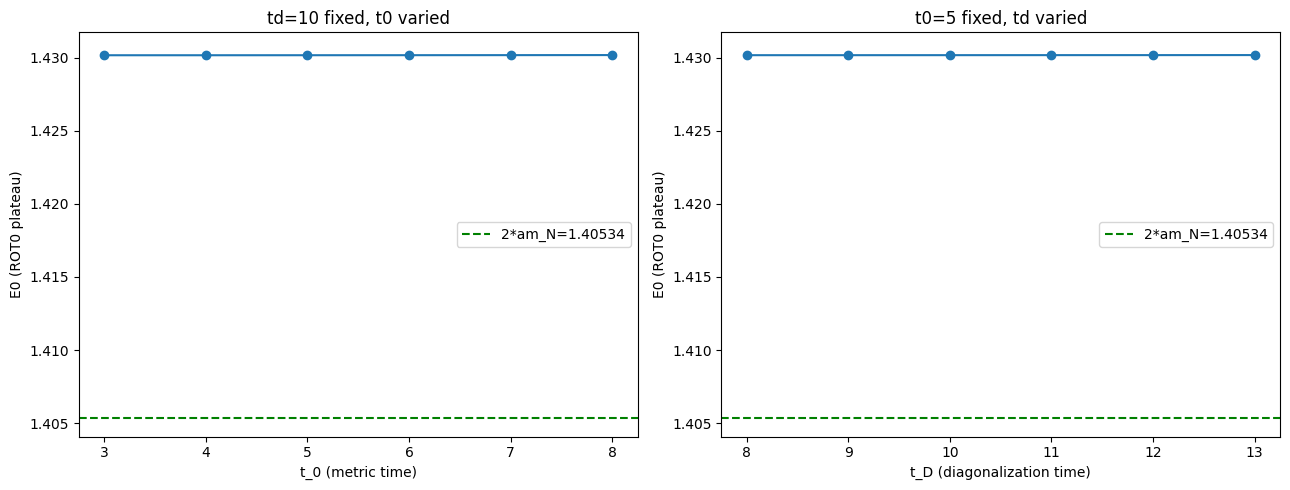

post-rotation Hermiticity violation: 0.0

Single-exp fit to D_00(t) over t in [4, 10]:
  A =1251.647593   (normalization artifact, not physics)
  E0=1.425216 +/- 0.000293


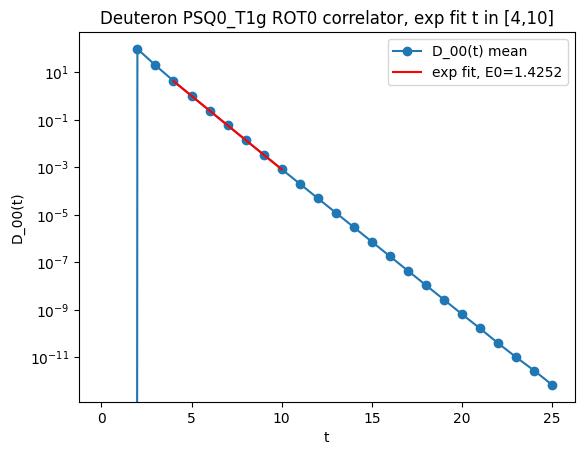


Constant fit to m_eff(t_s) over t_s in [4.5, 10.5]:
  E0=1.424008 +/- 0.000295


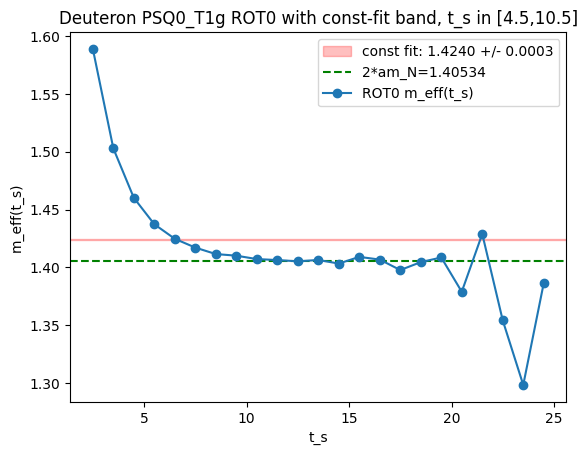


Summary for PSQ0_T1g:
  Single-exp fit E0 (t in [4,10])=1.425216 +/- 0.000293
  Constant fit E0 (t_s in [4.5,10.5]) =1.424008 +/- 0.000295
  2*am_N=1.405340


In [5]:
# Deuteron PSQ0_T1g: GEVP stability scan and single-exp and constant fits

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# load PSQ0_T1g
file_path="cosmon_c103_r005-8_deuteron_Swave.hdf5"
group="PSQ0_T1g"
with h5py.File(file_path, "r") as f:
    data=f[group]["data"][:] # (1490, 15, 15, 26)
N_samples, N_op, _, Nt=data.shape
print("group =", group)
print("N_samples =", N_samples, " N_op =", N_op, " Nt =", Nt)
print()

def symmetrize_single(C):
    return 0.5 * (C + np.conj(np.transpose(C, (1, 0, 2))))
def meff_from_diag(D_diag, t_start=2):
    D=D_diag.real
    Nt_local=D_diag.shape[0]
    t_lo=np.arange(t_start, Nt_local - 1)
    t_s=t_lo + 0.5
    C_lo=D[t_start:-1]
    C_hi=D[t_start + 1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio=C_lo / C_hi
        ratio=np.where(ratio > 0, ratio, np.nan)
        meff=np.log(ratio)
    return t_s, meff
def single_pivot_gevp(C_sym, t0, td):
    C_t0=C_sym[:, :, t0]
    C_td=C_sym[:, :, td]
    evals, evecs=eigh(C_td, C_t0)
    idx=np.argsort(evals)[::-1]
    evals=evals[idx]
    evecs=evecs[:, idx]
    gram=evecs.conj().T @ C_t0 @ evecs
    scale=np.sqrt(np.abs(np.diag(gram)))
    V=evecs / scale[np.newaxis, :]
    return evals, V
def rotate_all(C_sym, V):
    N_op_local=C_sym.shape[0]
    Nt_local=C_sym.shape[2]
    D=np.zeros((N_op_local, N_op_local, Nt_local), dtype=complex)
    for it in range(Nt_local):
        D[:, :, it] = V.conj().T @ C_sym[:, :, it] @ V
        D[:, :, it] = 0.5 * (D[:, :, it] + D[:, :, it].conj().T)
    return D
def bootstrap_E0_rot0(data, t0, td, t_lo, t_hi,nboot=1000, seed=12345, t_start=2):
    rng=np.random.default_rng(seed)
    C_mean=data.mean(axis=0)
    C_sym =symmetrize_single(C_mean)
    evals, V=single_pivot_gevp(C_sym, t0, td)
    E0_boot=np.full(nboot, np.nan)
    for b in range(nboot):
        idx=rng.integers(0, N_samples, size=N_samples)
        C_b=symmetrize_single(data[idx].mean(axis=0))
        D_b=rotate_all(C_b, V)
        ts_b, m_b=meff_from_diag(D_b[0, 0, :], t_start=t_start)
        mask=(ts_b >= t_lo) & (ts_b <= t_hi)
        E0_boot[b]=np.nanmean(m_b[mask])

    return np.nanmean(E0_boot), np.nanstd(E0_boot), evals

# Part 1: stability scan

t_lo_win=4.5
t_hi_win=8.5

td_fixed=10
t0_scan=[3, 4, 5, 6, 7, 8]

print("Scan A: td =", td_fixed, " fixed, t0 varied")
E0_vs_t0, E0err_vs_t0, cond_vs_t0=[], [], []
for t0 in t0_scan:
    E0, Eerr, evals=bootstrap_E0_rot0(data, t0, td_fixed, t_lo_win, t_hi_win)
    cond=np.max(np.abs(evals)) / np.min(np.abs(evals))
    E0_vs_t0.append(E0); E0err_vs_t0.append(Eerr); cond_vs_t0.append(cond)
    print(f"  t0={t0}, td={td_fixed}: E0={E0:.6f} +/- {Eerr:.6f}, cond={cond:.3f}")

t0_fixed=5
td_scan=[8, 9, 10, 11, 12, 13]

print()
print("Scan B: t0 =", t0_fixed, " fixed, td varied")
E0_vs_td, E0err_vs_td, cond_vs_td=[], [], []
for td in td_scan:
    E0, Eerr, evals=bootstrap_E0_rot0(data, t0_fixed, td, t_lo_win, t_hi_win)
    cond=np.max(np.abs(evals)) / np.min(np.abs(evals))
    E0_vs_td.append(E0); E0err_vs_td.append(Eerr); cond_vs_td.append(cond)
    print(f"  t0={t0_fixed}, td={td}: E0={E0:.6f} +/- {Eerr:.6f}, cond={cond:.3f}")

# ---- stability plots ----
fig, axes=plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(t0_scan, E0_vs_t0, yerr=E0err_vs_t0, fmt="o-")
axes[0].axhline(2 * 0.70267, color="green", linestyle="--",
                label="2*am_N=1.40534")
axes[0].set_xlabel("t_0 (metric time)")
axes[0].set_ylabel("E0 (ROT0 plateau)")
axes[0].set_title(f"td={td_fixed} fixed, t0 varied")
axes[0].legend()

axes[1].errorbar(td_scan, E0_vs_td, yerr=E0err_vs_td, fmt="o-")
axes[1].axhline(2 * 0.70267, color="green", linestyle="--",
                label="2*am_N=1.40534")
axes[1].set_xlabel("t_D (diagonalization time)")
axes[1].set_ylabel("E0 (ROT0 plateau)")
axes[1].set_title(f"t0={t0_fixed} fixed, td varied")
axes[1].legend()

plt.tight_layout()
plt.savefig("deuteron_stability_scan.png", dpi=150, bbox_inches="tight")
plt.show()

# Part 2: single-exponential fit to D_00(t) — linear fit to ln D_00

t0_fit=5
td_fit=10
C_mean=data.mean(axis=0)
C_sym =symmetrize_single(C_mean)
evals, V=single_pivot_gevp(C_sym, t0_fit, td_fit)
D_mean   = rotate_all(C_sym, V)          # shape (N_op, N_op, Nt)
D00_mean = D_mean[0, 0, :].real
max_violation = 0.0
for it in range(Nt):
    D_it = D_mean[:, :, it]
    v = np.max(np.abs(D_it - D_it.conj().T))
    max_violation = max(max_violation, v)
print("post-rotation Hermiticity violation:", max_violation)
t_min_fit=4
t_max_fit=10
t_arr=np.arange(Nt)
mask_fit=(t_arr >= t_min_fit) & (t_arr <= t_max_fit)
t_fit=t_arr[mask_fit]
D_fit=D00_mean[mask_fit]
log_D=np.log(D_fit)
coeffs=np.polyfit(t_fit, log_D, 1)
E0_exp=-coeffs[0]
A0=np.exp(coeffs[1])
rng=np.random.default_rng(12345)
E0_exp_boot=np.full(1000, np.nan)
for b in range(1000):
    idx=rng.integers(0, N_samples, size=N_samples)
    C_b=symmetrize_single(data[idx].mean(axis=0))
    D_b=rotate_all(C_b, V)
    D_b00=D_b[0, 0, :].real
    try:
        log_Db=np.log(D_b00[mask_fit])
        coeffs_b=np.polyfit(t_fit, log_Db, 1)
        E0_exp_boot[b]=-coeffs_b[0]
    except (ValueError, RuntimeWarning):
        pass
E0_exp_mean=np.nanmean(E0_exp_boot)
E0_exp_err =np.nanstd(E0_exp_boot)

print()
print(f"Single-exp fit to D_00(t) over t in [{t_min_fit}, {t_max_fit}]:")
print(f"  A ={A0:.6f}   (normalization artifact, not physics)")
print(f"  E0={E0_exp_mean:.6f} +/- {E0_exp_err:.6f}")
plt.figure()
plt.plot(t_arr, D00_mean, "o-", label="D_00(t) mean")
t_dense=np.linspace(t_min_fit, t_max_fit, 200)
plt.plot(t_dense, A0 * np.exp(-E0_exp * t_dense), "r-",label=f"exp fit, E0={E0_exp:.4f}")
plt.yscale("log")
plt.xlabel("t")
plt.ylabel("D_00(t)")
plt.title(f"Deuteron PSQ0_T1g ROT0 correlator, exp fit t in [{t_min_fit},{t_max_fit}]")
plt.legend()
plt.savefig("deuteron_exp_fit.png", dpi=150, bbox_inches="tight")
plt.show()

# Part 3: constant fit to m_eff(t_s) with red band
ts_mean, m_rot0_mean=meff_from_diag(D_mean[0, 0, :])
ts_lo_fit=t_min_fit + 0.5
ts_hi_fit=t_max_fit + 0.5
mask_ts=(ts_mean >= ts_lo_fit) & (ts_mean <= ts_hi_fit)
E0_const=np.nanmean(m_rot0_mean[mask_ts])
E0_const_boot=np.full(1000, np.nan)
rng2=np.random.default_rng(54321)
for b in range(1000):
    idx=rng2.integers(0, N_samples, size=N_samples)
    C_b=symmetrize_single(data[idx].mean(axis=0))
    D_b=rotate_all(C_b, V)
    ts_b, m_b=meff_from_diag(D_b[0, 0, :])
    mask_b=(ts_b >= ts_lo_fit) & (ts_b <= ts_hi_fit)
    E0_const_boot[b]=np.nanmean(m_b[mask_b])

E0_const_mean=np.nanmean(E0_const_boot)
E0_const_err =np.nanstd(E0_const_boot)
print()
print(f"Constant fit to m_eff(t_s) over t_s in [{ts_lo_fit}, {ts_hi_fit}]:")
print(f"  E0={E0_const_mean:.6f} +/- {E0_const_err:.6f}")
plt.figure()
plt.errorbar(ts_mean, m_rot0_mean, fmt="o-", label="ROT0 m_eff(t_s)")
plt.axhspan(E0_const_mean - E0_const_err, E0_const_mean + E0_const_err,color="red", alpha=0.25,label=f"const fit: {E0_const_mean:.4f} +/- {E0_const_err:.4f}")
plt.axhline(2 * 0.70267, color="green", linestyle="--",label="2*am_N=1.40534")
plt.xlabel("t_s")
plt.ylabel("m_eff(t_s)")
plt.title(f"Deuteron PSQ0_T1g ROT0 with const-fit band, t_s in [{ts_lo_fit},{ts_hi_fit}]")
plt.legend()
plt.savefig("deuteron_const_band.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Summary for PSQ0_T1g:")
print(f"  Single-exp fit E0 (t in [{t_min_fit},{t_max_fit}])={E0_exp_mean:.6f} +/- {E0_exp_err:.6f}")
print(f"  Constant fit E0 (t_s in [{ts_lo_fit},{ts_hi_fit}]) ={E0_const_mean:.6f} +/- {E0_const_err:.6f}")
print(f"  2*am_N={2*0.70267:.6f}")